In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# custom modules
import sys
import os
sys.path.append(os.path.abspath("../src"))

from data_preprocessing import load_data, preprocess_data
from model_training import train_logistic, train_knn
from evaluation import evaluate_model

In [4]:
df =pd.read_csv('C:/Users/vijay/OneDrive/Desktop/netflix/ML_01/Netflix-Customer-Churn-Prediction/data/net.csv')

df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [6]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

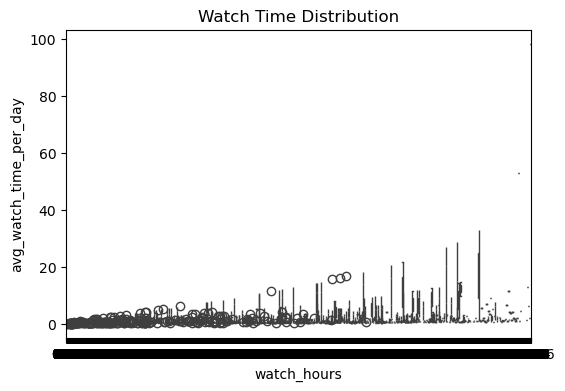

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, y='avg_watch_time_per_day', x='watch_hours')
plt.title("Watch Time Distribution")

plt.show()
plt.savefig("../images/boxplot.png")

In [9]:
X_train, X_test, y_train, y_test, scaler = preprocess_data(df)

In [10]:
lr_model = train_logistic(X_train, y_train)

In [11]:
lr_acc, lr_cm = evaluate_model(lr_model, X_test, y_test)

print("Logistic Regression Accuracy:", lr_acc)
print("Confusion Matrix:\n", lr_cm)

Logistic Regression Accuracy: 0.8963636363636364
Confusion Matrix:
 [[738 101]
 [ 70 741]]


In [12]:
knn_model = train_knn(X_train, y_train)

In [13]:
knn_acc, knn_cm = evaluate_model(knn_model, X_test, y_test)

print("KNN Accuracy:", knn_acc)
print("Confusion Matrix:\n", knn_cm)

KNN Accuracy: 0.730909090909091
Confusion Matrix:
 [[614 225]
 [219 592]]


In [14]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [lr_acc, knn_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.896364
1,KNN,0.730909


In [17]:
import os
print(os.getcwd())

c:\Users\vijay\OneDrive\Desktop\netflix\ML_01\Netflix-Customer-Churn-Prediction\notebooks


In [20]:
import os
import pickle

# folder create
os.makedirs("../models", exist_ok=True)

# correct variable name use karo
with open("../models/model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Model saved successfully!")

Model saved successfully!
